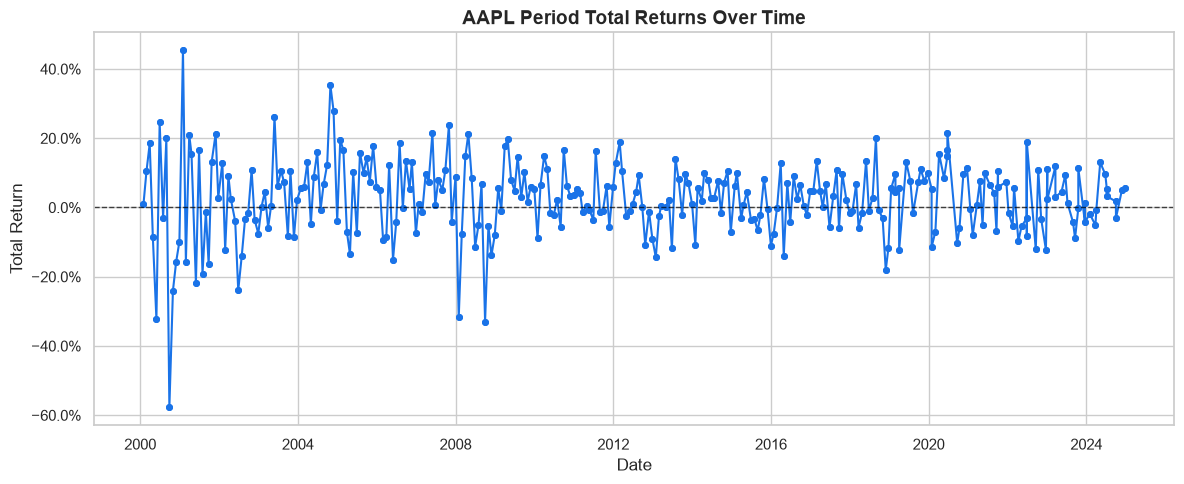

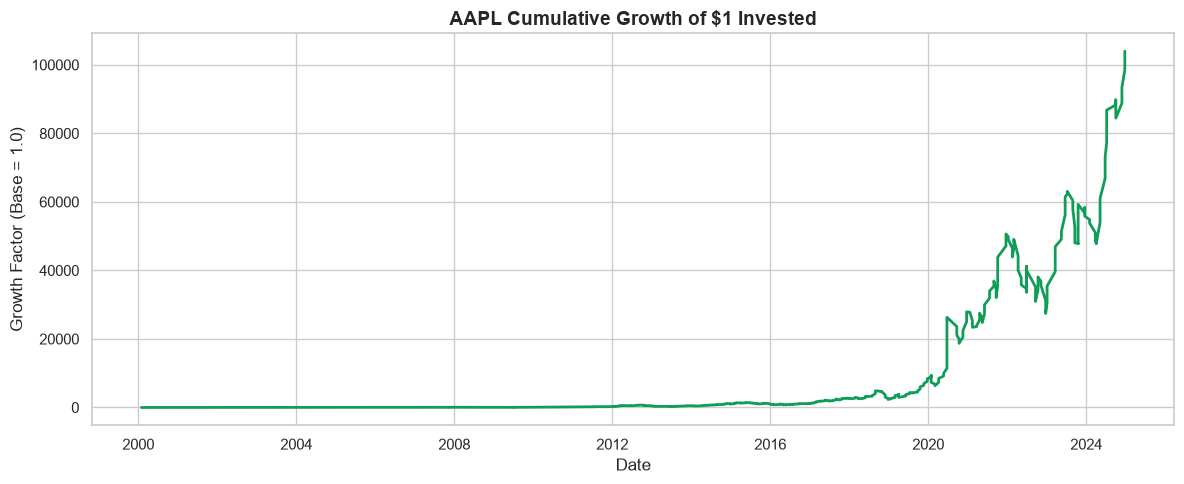

In [2]:
# In[1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# In[2]:

df = pd.read_parquet("/Users/nwk/Documents/SMU/QA600_AsssetPricing/backtest_project/data/processed/backtest_master_panel.parquet")

# Inspect the schema and head
df.head()

# In[3]:
# 2. Filter for Apple (AAPL) and preprocess dates
aapl_df = df[df["ticker"] == "AAPL"].copy()

# Convert epoch milliseconds to datetime format
aapl_df["date"] = pd.to_datetime(aapl_df["snapshot_date"], unit="ms")

# Sort chronologically
aapl_df = aapl_df.sort_values("date")

# Ensure total_return is numeric
aapl_df["total_return"] = pd.to_numeric(aapl_df["total_return"])

# In[4]:
# 3. Compute Cumulative Return Index (Growth of $1)
# Assuming total_return represents period-over-period simple return
aapl_df["cumulative_return"] = (1 + aapl_df["total_return"]).cumprod()

aapl_df[["date", "ticker", "price", "total_return", "cumulative_return"]].head()

# In[5]:
# 4. Plot Monthly/Period Returns
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    aapl_df["date"],
    aapl_df["total_return"],
    color="#1a73e8",
    linewidth=1.5,
    marker="o",
    markersize=4,
)
ax.axhline(0, color="black", linestyle="--", alpha=0.7, linewidth=1)

ax.set_title("AAPL Period Total Returns Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Total Return", fontsize=12)
ax.yaxis.set_major_formatter("{x:.1%}")  # Format Y-axis as percentage

plt.tight_layout()
plt.show()

# In[6]:
# 5. Plot Cumulative Performance (Growth of $1)
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    aapl_df["date"],
    aapl_df["cumulative_return"],
    color="#0f9d58",
    linewidth=2,
)

ax.set_title(
    "AAPL Cumulative Growth of $1 Invested", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Growth Factor (Base = 1.0)", fontsize=12)

plt.tight_layout()
plt.show()

Total Observations: 511,630
Unique Stocks (PERMNOs): 1,061
Date Range: 2000-01-31 to 2024-12-31

--- Momentum Signal Descriptive Statistics ---
count    511630.000000
mean          0.257253
std           1.169617
min          -0.998361
1%           -0.844892
5%           -0.601126
50%           0.114748
95%           1.451462
99%           3.117624
max          86.104357
Name: momentum_12_1, dtype: float64


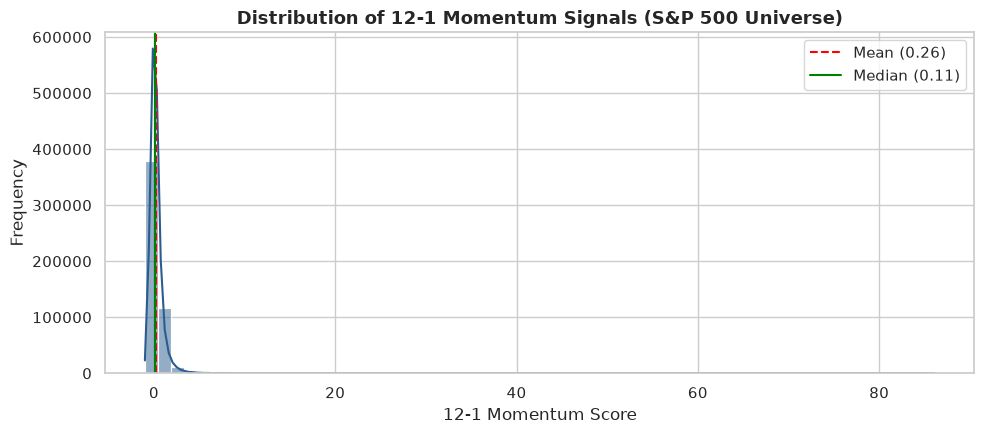

In [ ]:
# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Load panel with computed momentum signals
df = pd.read_parquet("/Users/nwk/Documents/SMU/QA600_AsssetPricing/backtest_project/data/processed/backtest_panel_with_signals.parquet")


df['rebalance_date'] = pd.to_datetime(df['rebalance_date'])

print(f"Total Observations: {len(df):,}")
print(f"Unique Stocks (PERMNOs): {df['permno'].nunique():,}")
print(f"Date Range: {df['rebalance_date'].min().strftime('%Y-%m-%d')} to {df['rebalance_date'].max().strftime('%Y-%m-%d')}")

# ==========================================
# 2. SIGNAL DISTRIBUTION & OUTLIER ANALYSIS
# ==========================================
# Check summary metrics
stats = df['momentum_12_1'].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
print("\n--- Momentum Signal Descriptive Statistics ---")
print(stats)

plt.figure(figsize=(10, 4.5))
sns.histplot(df['momentum_12_1'], bins=60, kde=True, color='#2b5c8f')
plt.axvline(stats['mean'], color='red', linestyle='--', label=f"Mean ({stats['mean']:.2f})")
plt.axvline(stats['50%'], color='green', linestyle='-', label=f"Median ({stats['50%']:.2f})")
plt.title('Distribution of 12-1 Momentum Signals

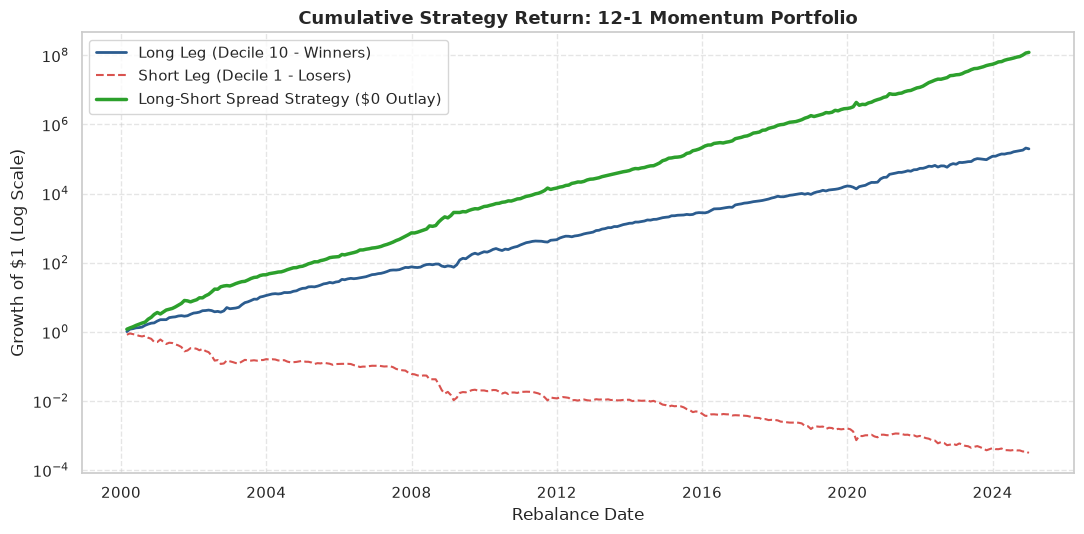

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("/Users/nwk/Documents/SMU/QA600_AsssetPricing/backtest_project/data/processed/momentum_strategy_returns.parquet")
df['rebalance_date'] = pd.to_datetime(df['rebalance_date'])
df = df.sort_values('rebalance_date').reset_index(drop=True)

# Compute Cumulative Growth of $1
df['Cum_Long'] = (1 + df['Long_Leg']).cumprod()
df['Cum_Short'] = (1 + df['Short_Leg']).cumprod()
df['Cum_Spread'] = (1 + df['Long_Short_Spread']).cumprod()

# Plot Cumulative Returns
plt.figure(figsize=(11, 5.5))
plt.plot(df['rebalance_date'], df['Cum_Long'], label='Long Leg (Decile 10 - Winners)', color='#2b5c8f', linewidth=2)
plt.plot(df['rebalance_date'], df['Cum_Short'], label='Short Leg (Decile 1 - Losers)', color='#d9534f', linewidth=1.5, linestyle='--')
plt.plot(df['rebalance_date'], df['Cum_Spread'], label='Long-Short Spread Strategy ($0 Outlay)', color='#2ca02c', linewidth=2.5)

plt.title('Cumulative Strategy Return: 12-1 Momentum Portfolio', fontsize=13, fontweight='bold')
plt.xlabel('Rebalance Date')
plt.ylabel('Growth of $1 (Log Scale)')
plt.yscale('log')  # Log scale for compounding asset growth
plt.legend(loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

/var/folders/j9/d9rctrpj63zdz0rdr_9wtg8m0000gn/T/ipykernel_13951/4257630621.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=[f"D{i}" for i in range(1, 11)], y=mean_decile_returns.values, palette=colors)


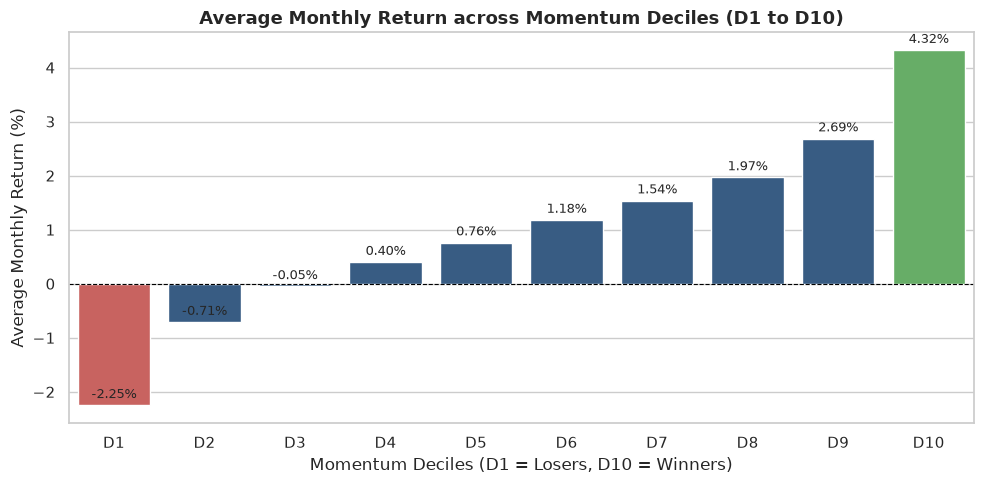

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load full monthly returns parquet file
df = pd.read_parquet("/Users/nwk/Documents/SMU/QA600_AsssetPricing/backtest_project/data/processed/momentum_strategy_returns.parquet")

# 1. Compute Mean Return Across Deciles
decile_cols = [f'Decile_{i}' for i in range(1, 11)]
mean_decile_returns = df[decile_cols].mean() * 100  # Convert to %

# 2. Plot Monotonicity Bar Chart
plt.figure(figsize=(10, 5))
colors = ['#d9534f' if i == 0 else ('#2b5c8f' if i < 9 else '#5cb85c') for i in range(10)]
ax = sns.barplot(x=[f"D{i}" for i in range(1, 11)], y=mean_decile_returns.values, palette=colors)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Average Monthly Return across Momentum Deciles (D1 to D10)', fontsize=13, fontweight='bold')
plt.xlabel('Momentum Deciles (D1 = Losers, D10 = Winners)')
plt.ylabel('Average Monthly Return (%)')

# Add values above bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()